In [113]:
import pandeia.engine
import stsynphot
import synphot
from synphot import SpectralElement
from synphot.models import Empirical1D
import os, glob, sys
import numpy as np
from astropy.io import fits
import astropy.units as u
import astropy.constants as const
from scipy import interpolate
from scipy.integrate import simpson
import matplotlib.pyplot as plt
%matplotlib inline

In [114]:
dustdir = 'data/dust/'

# RSG models for range of temperatures
temp=[2600,2800,3000,3200,3300,3400,3500,3600,3700,3800,3900,4000,
            4250,4500,5000,6000,7000,8000]
temp = np.array(temp)

# This is the total integrated flux of a source with Lum = 1 Lsun in units of
# erg/s/cm2.  Used to renormalize the RSG spectrum.  This is equivalent to
# 3.839e33/(4 * pi * (10 * 3.08568025e18)^2) for 1 Lsol at 10 pc.
FLUX_SCALE = 3.22398177e-7

# Dust-to-gas mass ratio assumption
DUST_TO_GAS = 0.01

data10 = np.loadtxt(dustdir+'data10.dat', unpack=True, dtype=float)

kappa = np.loadtxt(dustdir+'dust01_trans.dat')
wavelength = np.loadtxt(dustdir+'wavelength.dat')

def rebin(a, newshape):
    newarray = np.zeros(newshape)
    curr = 0
    for i in np.arange(newshape):
        s = slice(curr, curr+int(a.shape[0]/newshape), 1)
        newarray[i] = np.mean(a[s])
        curr += int(a.shape[0]/newshape)
    return(newarray)

wavelength = rebin(wavelength, 7748)
rsg_10 = interpolate.RegularGridInterpolator((wavelength, temp), data10.T, method='cubic', bounds_error=False)

# to interpolate
# xnew, ynew = np.meshgrid(wavelength_array, temp_array, indexing='ij', sparse=True)
# znew = rsg_10((xnew, ynew))

In [115]:
def get_avg2(x, p):
    l=x*1.0e-4
    t=p/10.0
    tgra1 = (0.500446 + 1.795729*t - 1.877658*t*t + 0.852820*t**3 - 0.141635*t**4)
    tgra2 = (4.318269 - 14.236698*t + 13.804110*t*t - 5.991369*t**3+0.959539*t**4)/l
    tgra3 = (-5.114167 + 32.462564*t - 26.895305*t*t + 10.197398*t**3 - 1.414338*t**4)/l**2
    tgra4 = (3.384105 - 21.107633*t + 12.229167*t*t - 2.172318*t**3 - 0.149866*t**4)/l**3
    tgra5 = (-1.059677 + 5.553703*t - 1.527415*t*t - 0.881450*t**3+0.391763*t**4)/l**4
    tgra6 = (0.121772 - 0.518968*t - 0.048566*t*t + 0.248002*t**3 - 0.077054*t**4)/l**5
    agraphite2 = (tgra1 + tgra2 + tgra3 + tgra4 + tgra5 + tgra6)*t*l**(-1.375229)

    return(agraphite2)

In [116]:
def get_dust(x, p, model='g2'):

    if model=='g2': 
        dust = get_avg2(x, p)
    else:
        raise NotImplementedError('Only model "g2" is currently available')

    dust[np.where(dust < 0)] = 0

    return(dust)

In [117]:
def get_rsg(scale, temp, model='10'):

    wavelength_grid, temp_grid = np.meshgrid(wavelength, temp, indexing='ij', sparse=True)
    if model == '10': 
        flux = rsg_10((wavelength_grid, temp_grid))
        flux = flux.flatten()
    else: 
        raise NotImplementedError('Only model "10" is currently available')

    normalize = simpson(flux, x=wavelength)
    # Renormalize the RSG spectrum so it's in units of erg/s/cm2/angstrom for
    # synphot to interpret
    flux = scale * FLUX_SCALE * flux/normalize

    return(flux)

In [122]:
def get_ext_bb(p, rsg_model='10', dust_model='g2', sptype='all', masked=True):

    w = wavelength
    flux = get_rsg(p[1], p[2], model=rsg_model)

    if masked and len(w)!=5157: #5157?
        mask = (wavelength > 3500.0) & (wavelength < 1.0e5) #why upper limit?
        kappa = np.loadtxt(dustdir+'dust01_trans.dat')
        w = w[mask]
        flux = flux[mask]
        kappa = kappa[mask]

    if sptype=='i' or sptype=='intrinsic':
        sp = synphot.SourceSpectrum(Empirical1D, points=w, lookup_table=flux)
        return(sp)

    a_dust = get_dust(w, p[0], model=dust_model)
    obsflux = flux * 10**(-0.4*a_dust)
    bb_scale = simpson(flux-obsflux, x=w)

    if sptype=='s' or sptype=='star':
        sp = synphot.SourceSpectrum(Empirical1D, points=w, lookup_table=obsflux)
        return(sp)

    bb = kappa * (w*1.0e-5)**-5 * 1.0/(np.exp(143843215.0/(w*p[3]))-1.0)
    # We also need to renormalize the bb flux.  The fraction of total luminosity
    # in the bb part of the spectrum is "scale".  So here we can simply multiply
    # by p[1] * FLUX_SCALE
    normalize_bb = simpson(bb, x=w)
    bb = bb_scale * bb / normalize_bb

    if sptype=='b' or sptype=='bb' or sptype=='dust' or sptype=='blackbody':
        sp = synphot.SourceSpectrum(Empirical1D, points=w, lookup_table=bb)
    elif sptype=='ss' or sptype=='scaled_star':
        sp = synphot.SourceSpectrum(Empirical1D, points=w, lookup_table=obsflux)
    else:
        sp = synphot.SourceSpectrum(Empirical1D, points=w, lookup_table=obsflux + bb)
        mask = sp(sp.waveset) < 0

    if sptype=='all':
        Lsol = simpson(sp(sp.waveset), x=sp.waveset)*4*np.pi*(10*3.08568025e18)**2/(3.839e33)
        try:
            assert np.abs((Lsol-p[1])/p[1]) < 3.0e-2
        except AssertionError:
            print(p)
            print(Lsol)
            print(np.abs((Lsol-p[1])/p[1]))
            print(rsg_model, dust_model, masked)
            sys.exit()

    return(sp)

In [123]:
class rsg_phot(object):
    def __init__(self, verbose=True, interpolate=True):
        self.filename = ''

        try:
            self.pandeia = os.environ['pandeia_refdata']
        except:
            print('WARNING: if using JWST filters, set PANDEIA env variable')
            self.pandeia = None

        # Magnitude system of input data (AB is usually best)
        self.magsystem = 'abmag'

        # Storing model data and magnitudes for models
        self.models = None
        self.model_mags = {}

        self.model_size = 1000
        self.ages_shape = [0, 0, self.model_size]
        self.mass_shape = [0, 0, self.model_size]

        self.phottable = None
        self.backend = None
        self.pickles_data = None
        self.verbose = verbose

        self.all_ages = []
        self.all_masses = []

        self.model_type = ''
        self.model_fit_params = []
        self.model_fit_blobs = []

        self.mist_masses = list(np.arange(7.5, 40.0, 0.5))
        add_masses = list(np.arange(8.0,15.0,0.1))
        add_masses = [int(m*10.0)*1.0/10.0 for m in add_masses]
        self.mist_masses = np.array(np.unique(self.mist_masses+add_masses))
        self.metallicity = 0.014 # Metallicity in terms of Z

        # Distance and uncertainty in Mpc
        self.distance = [12.3, 1.8]
        self.dm = 5.0 * np.log10(self.distance[0]) + 25.0

        # For extinction likelihood values to use as a prior for modeling
        self.extinction = {
            'Av': None, 'Rv': None, 'pdf': None, 'cdf': None,
            'interpolation': None, 'likelihood': False,
            # For the extinction in a particular bandpass given Av,Rv
            'function': {}
        }

        # A list of rv values for input filters
        self.rv = []

        # Default wavelength binset in angstroms for pysynphot
        self.waves = 3500.0 + 10.0*np.arange(9650)
        self.bandpasses = None

        self.bounds = {
            'luminosity': [-1.0, 7.0],
            'temperature': [800., 100000.],
            'tau_V': [0.01, 6.0],
            'dust_temp': [200., 2000.],
            'mass': [0.1, 120.0],
            'age': [1.0e4, 13.0e9],
            'period': [0.0, 4.0], # in log10(days)
            'ratio': [0.1, 0.9],
            'Av': [0.0, 6.0],
            'Rv': [2.0, 6.0]
        }

    def get_jwst_filters(self, filtnam):

        tel, inst, filt = filtnam.split(',')
        filt = filt.lower()
        inst = inst.lower()
        
        globstr = os.path.join(self.pandeia, 'jwst', inst, 'filters', f'*{filt}_trans*')
        filts = glob.glob(globstr)
        
        if len(filts)!=1:
            return None
        
        f = filts[0]
        
        base = os.path.split(f)[1]
        name = inst.lower()+'_'+filt.lower()
        hdu = fits.open(f)
        wave = np.array([float(el[0])*1.0e4 for el in hdu[1].data])
            
        tran = np.array([float(el[1]) for el in hdu[1].data])
            
        # Only consider wavelengths < 30 microns
        mask = wave < 30.0*1.0e4
        wave = wave[mask]
        tran = tran[mask]
            
        bp = SpectralElement(Empirical1D, points=wave, lookup_table=tran)
            
        return bp
        
    def create_rsg(self, tau_V, lum, temp, dust_temp, sptype='all'):
        # RSG model takes luminosity in Lsol as input
        scaled_lum = 10**lum
        spec = get_ext_bb((tau_V, scaled_lum, temp, dust_temp),
            sptype=sptype)

        return(spec)
        
    def compute_rsg_mag(self, inst_filt, tau_V, lum, temp, dust_temp):

        # Scale spectrum up to input luminosity
        sp = self.create_rsg(tau_V, lum, temp, dust_temp)

        # Get bandpasses and compute mags
        bandpasses = self.get_bandpasses(inst_filt)
        mags = self.compute_pysynphot_mag(sp, bandpasses)

        return(mags)

In [124]:
syn_rsg = rsg_phot()

In [125]:
rsgspec = syn_rsg.create_rsg(1, 1, 4000, 2000)

Text(0, 0.5, 'Flux (PHOTLAM)')

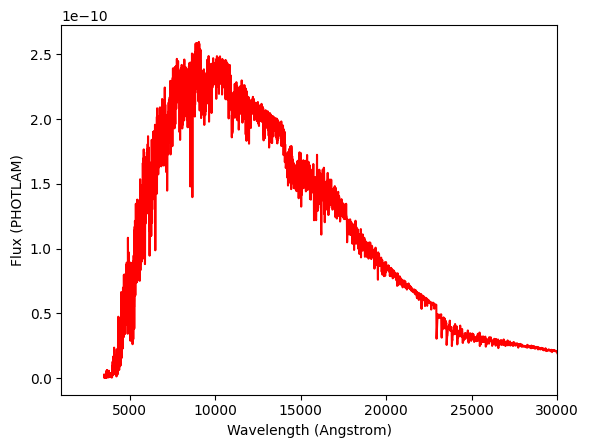

In [126]:
wvs = rsgspec.waveset
plt.plot(wvs, rsgspec(wvs), 'r')
plt.xlim(1000, 30000)
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux (PHOTLAM)')